In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew

In [134]:
df = pd.read_excel('../data/raw/first_task.xlsx')
df.head()

,"Symptoms: 1-angina, 2-probable angina, 3 - without angina",Angina range,"Depression of the ST-1 >2 mm, 2-1-2 mm, 3-without depression",ECG range,WMSI stress,D WMSI,WMSI range,FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)
0,3,0,3,0,1.000,0.000,0,1.0
1,3,0,3,0,1.125,0.000,0,1.0
2,3,0,3,0,1.125,0.125,1,0.0
3,1,1,3,0,1.000,-0.190,1,1.0
4,3,0,3,0,1.120,0.120,1,0.0


In [135]:
df.shape

(516, 8)

In [136]:
df = df.rename(columns={'FU1+2+3+4 coronary event (Death+AMI+ACS+Revasc)': 'target', 'Symptoms: 1-angina, 2-probable angina, 3 - without angina': 'symptoms', 'Depression of the ST-1 >2 mm, 2-1-2 mm, 3-without depression': 'depression'})
df.head()

,symptoms,Angina range,depression,ECG range,WMSI stress,D WMSI,WMSI range,target
0,3,0,3,0,1.000,0.000,0,1.0
1,3,0,3,0,1.125,0.000,0,1.0
2,3,0,3,0,1.125,0.125,1,0.0
3,1,1,3,0,1.000,-0.190,1,1.0
4,3,0,3,0,1.120,0.120,1,0.0


In [137]:
df.isna().sum()

symptoms         0
Angina range     0
depression       0
ECG range        0
WMSI stress      0
D WMSI           0
WMSI range       0
target          14
dtype: int64

In [138]:
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = df.drop_duplicates().shape[0]

print(f"Всего строк: {total_rows}")
print(f"Уникальных строк: {unique_rows}")
print(f"Дублирующихся строк: {duplicate_rows}")
print(f"Процент дубликатов: {duplicate_rows/total_rows*100:.2f}%")

Всего строк: 516
Уникальных строк: 164
Дублирующихся строк: 352
Процент дубликатов: 68.22%


<Axes: >

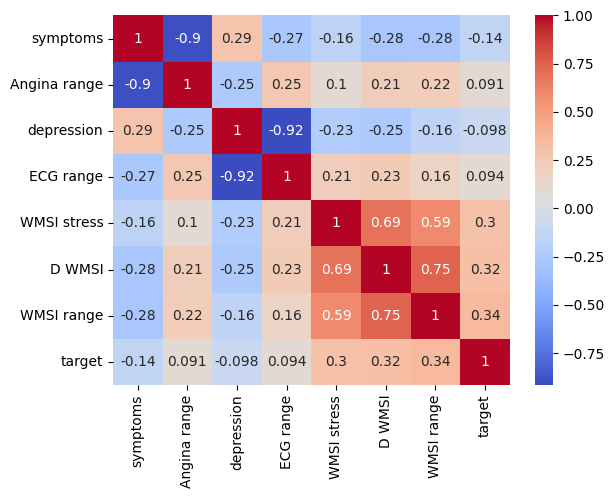

In [140]:
sns.heatmap(df.corr(), cmap = 'coolwarm', annot = True)

In [141]:
df['target'].value_counts()

target
0.0    369
1.0    133
Name: count, dtype: int64

In [142]:
df['target'].value_counts(normalize=True)

target
0.0    0.73506
1.0    0.26494
Name: proportion, dtype: float64

In [143]:
df['symptoms'].value_counts()

symptoms
3    264
2    172
1     80
Name: count, dtype: int64

In [144]:
df['depression'].value_counts()

depression
3    338
2    135
1     43
Name: count, dtype: int64

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

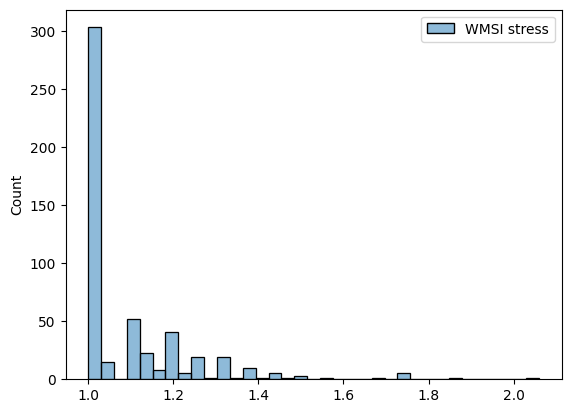

In [145]:
sns.histplot(df[['WMSI stress']])

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this war

<Axes: ylabel='Count'>

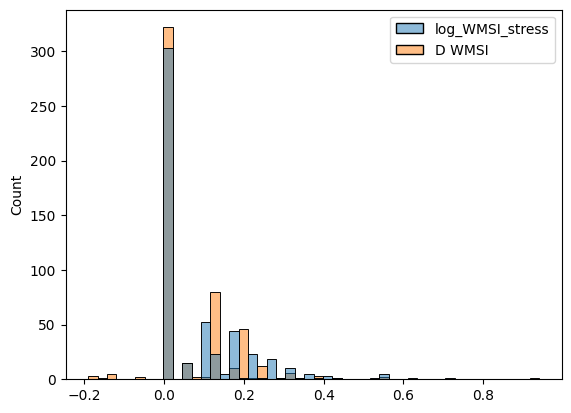

In [146]:
df['log_WMSI_stress'] = np.log(df['WMSI stress'])
sns.histplot(df[['log_WMSI_stress', 'D WMSI']])

In [147]:
print(skew(df['WMSI stress']))
print(skew(df['log_WMSI_stress']))

2.4408342490984323
1.8587256907766554


In [148]:
df['WMSI range'].value_counts()

WMSI range
0    343
1    173
Name: count, dtype: int64

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['Angina range'], df['target'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square p-value: {p:.4f}")

Chi-square p-value: 0.0523


In [151]:
df.columns

Index(['symptoms', 'Angina range', 'depression', 'ECG range', 'WMSI stress',
       'D WMSI', 'WMSI range', 'target', 'log_WMSI_stress'],
      dtype='object')

In [152]:
for col in df.columns:
    if col not in ['target', 'WMSI stress', 'D WMSI', 'log_WMSI_stress']:
        print(f"\n{'='*50}")
        print(f"=== {col} vs target ===")
        print('='*50)
        
        cross = pd.crosstab(df[col], df['target'], normalize='index')
        print(cross)
        print()


=== symptoms vs target ===
target         0.0       1.0
symptoms                    
1         0.575000  0.425000
2         0.751515  0.248485
3         0.774319  0.225681


=== Angina range vs target ===
target             0.0       1.0
Angina range                    
0             0.774319  0.225681
1             0.693878  0.306122


=== depression vs target ===
target           0.0       1.0
depression                    
1           0.627907  0.372093
2           0.699248  0.300752
3           0.763804  0.236196


=== ECG range vs target ===
target          0.0       1.0
ECG range                    
0          0.765244  0.234756
1          0.678161  0.321839


=== WMSI range vs target ===
target           0.0       1.0
WMSI range                    
0           0.843373  0.156627
1           0.523529  0.476471



c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='log_WMSI_stress'>

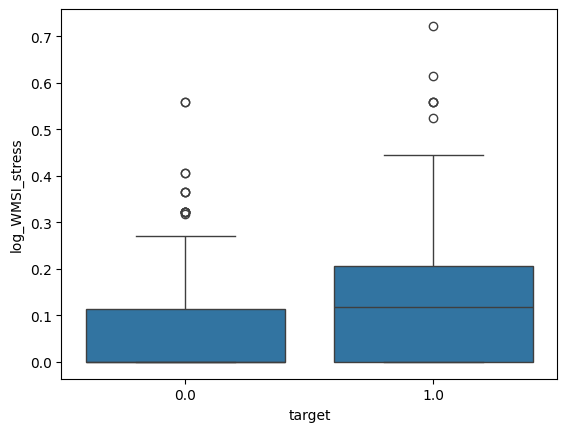

In [153]:
sns.boxplot(x='target', y='log_WMSI_stress', data=df)

c:\Users\Nikita Yevdokimov\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: xlabel='target', ylabel='D WMSI'>

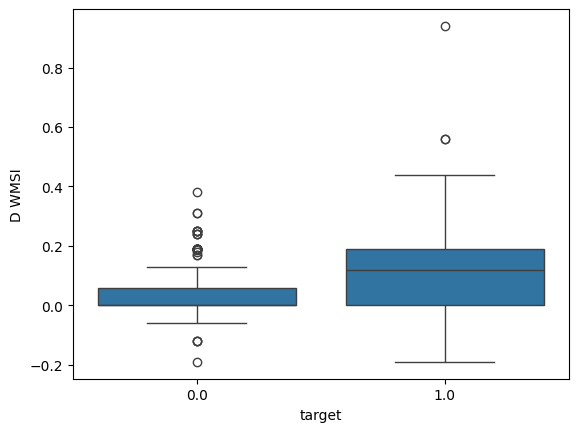

In [155]:
sns.boxplot(x='target', y='D WMSI', data=df)

Низкие значения D WMSI ассоциируется с низким прогнозом

In [156]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns = 'target').dropna()

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data['feature'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) 
                   for i in range(X_with_const.shape[1])]

vif_data = vif_data[vif_data['feature'] != 'const']

print(vif_data.sort_values('VIF', ascending=False))

            feature         VIF
8   log_WMSI_stress  225.540589
5       WMSI stress  188.339670
3        depression    6.465188
4         ECG range    6.344601
1          symptoms    5.487596
2      Angina range    5.251607
9  WMSI_stress_high    4.398033
7        WMSI range    3.696861
6            D WMSI    3.120503


In [157]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

def quick_feature_analysis(df, target_col):
    
    print(f"{'Признак':<25} {'Тип':<12} {'Тест':<15} {'p-value':<12} {'Значимо'}")
    print("-" * 80)
    
    for col in df.columns:
        if col == target_col:
            continue
        
        if df[col].nunique() < 10:
            contingency = pd.crosstab(df[col], df[target_col])
            
            if contingency.shape[0] == 2 and contingency.shape[1] == 2:
                _, p = fisher_exact(contingency)
                test_name = "Fisher"
            else:
                _, p, _, _ = chi2_contingency(contingency)
                test_name = "Chi-square"
            
            feat_type = "категориальный"
            
        else:
            g0 = df[df[target_col]==0][col].dropna()
            g1 = df[df[target_col]==1][col].dropna()
            _, p = mannwhitneyu(g0, g1, alternative='two-sided')
            test_name = "Mann-Whitney"
            feat_type = "непрерывный"
        
        significant = "✅" if p < 0.05 else "❌"
        print(f"{col:<25} {feat_type:<12} {test_name:<15} {p:.6f}    {significant}")

quick_feature_analysis(df, 'target')

Признак                   Тип          Тест            p-value      Значимо
--------------------------------------------------------------------------------
symptoms                  категориальный Chi-square      0.001672    ✅
Angina range              категориальный Fisher          0.043538    ✅
depression                категориальный Chi-square      0.090988    ❌
ECG range                 категориальный Fisher          0.043264    ✅
WMSI stress               непрерывный  Mann-Whitney    0.000000    ✅
D WMSI                    непрерывный  Mann-Whitney    0.000000    ✅
WMSI range                категориальный Fisher          0.000000    ✅
log_WMSI_stress           непрерывный  Mann-Whitney    0.000000    ✅
WMSI_stress_high          категориальный Fisher          0.000000    ✅


По таким результатам можно сделать вывод, что только признак depression не имеет статистической значимой связи между им и таргетом

In [158]:
from sklearn.metrics import roc_auc_score, roc_curve
df_without_nan = df.dropna()
auc = roc_auc_score(df_without_nan['target'], df_without_nan['log_WMSI_stress'])
print(f"AUC для log WMSI: {auc:.3f}")

auc = roc_auc_score(df_without_nan['target'], df_without_nan['D WMSI'])
print(f"AUC для D WMSI: {auc:.3f}")

auc = roc_auc_score(df_without_nan['target'], df_without_nan['WMSI range'])
print(f"AUC для WMSI range: {auc:.3f}")

AUC для log WMSI: 0.686
AUC для D WMSI: 0.681
AUC для WMSI range: 0.684
